# Lecture 8: Stabilization Policy with Rational Expectations

This notebook accompanies the lecture slides. It keeps the algebra light and focuses on the mechanisms:

1. static versus rational expectations in a credible disinflation,
2. when systematic policy is ineffective,
3. when current-information policy can stabilize shocks,
4. credibility, inflation bias, and mixed expectations.

Run the notebook from top to bottom.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
})

## 1. Static expectations versus rational expectations

Static expectations use last period's inflation as today's forecast:

\[
\pi^e_{t,t-1}=\pi_{t-1}.
\]

Rational expectations use the model and the policy announcement. In a perfectly credible disinflation, expected inflation can move immediately to the new target.

In [2]:
T = 35
pi_initial = 12.0
pi_star = 2.0
beta = 0.90

period = np.arange(T + 1)
pi_static = pi_star + (beta ** period) * (pi_initial - pi_star)
pi_e_static = np.r_[pi_initial, pi_static[:-1]]
pi_re = np.r_[pi_initial, np.full(T, pi_star)]

inflation_df = pd.DataFrame({
    "period": period,
    "actual_static": pi_static,
    "expected_static": pi_e_static,
    "credible_RE": pi_re,
})

inflation_df.head()

,period,actual_static,expected_static,credible_RE
0,0,12.000,12.00,12.0
1,1,11.000,12.00,2.0
2,2,10.100,11.00,2.0
3,3,9.290,10.10,2.0
4,4,8.561,9.29,2.0


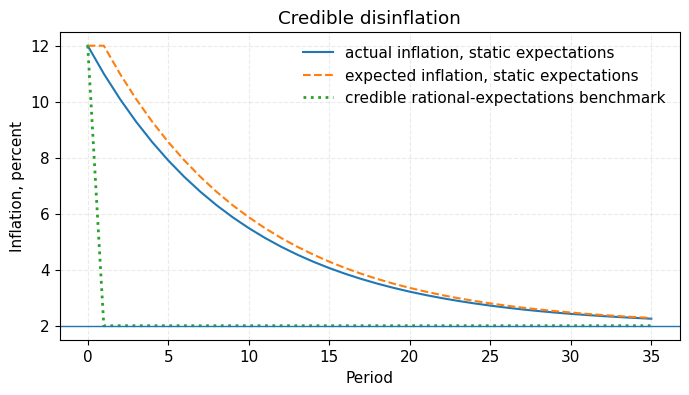

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(inflation_df["period"], inflation_df["actual_static"], label="actual inflation, static expectations")
ax.plot(inflation_df["period"], inflation_df["expected_static"], linestyle="--", label="expected inflation, static expectations")
ax.plot(inflation_df["period"], inflation_df["credible_RE"], linestyle=":", linewidth=2, label="credible rational-expectations benchmark")
ax.axhline(pi_star, linewidth=1)
ax.set_title("Credible disinflation")
ax.set_xlabel("Period")
ax.set_ylabel("Inflation, percent")
ax.legend(frameon=False)
plt.show()

**Interpretation.** Static expectations make disinflation slow because people keep forecasting from last period's inflation. Rational expectations can make the transition much faster if the policy announcement is credible.

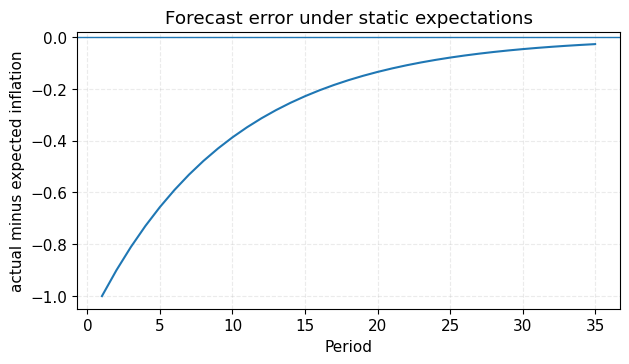

The sign of the forecast error is the same throughout the transition: -1


In [4]:
forecast_error = inflation_df["actual_static"] - inflation_df["expected_static"]

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(inflation_df["period"][1:], forecast_error[1:])
ax.axhline(0, linewidth=1)
ax.set_title("Forecast error under static expectations")
ax.set_xlabel("Period")
ax.set_ylabel("actual minus expected inflation")
plt.show()

print(f"The sign of the forecast error is the same throughout the transition: {np.sign(forecast_error[1]).astype(int)}")

## 2. Policy ineffectiveness with equal information

The policy ineffectiveness proposition says that predictable monetary policy cannot systematically move output if agents have rational expectations and the central bank has no information advantage.

A compact impact version is:

\[
\widehat y_t = v_t - \alpha_2\widehat\rho_t,
\qquad
\widehat\pi_t = \gamma v_t + s_t - \alpha_2\gamma\widehat\rho_t.
\]

The policy coefficients do not appear in these expressions.

In [5]:
alpha2 = 1.0
Gamma = 0.5

shocks = pd.DataFrame({
    "scenario": ["demand shock", "supply shock", "spread shock"],
    "v": [1.0, 0.0, 0.0],
    "s": [0.0, 1.0, 0.0],
    "rho_hat": [0.0, 0.0, 1.0],
})

shocks["y_gap_old_info"] = shocks["v"] - alpha2 * shocks["rho_hat"]
shocks["pi_gap_old_info"] = Gamma * shocks["v"] + shocks["s"] - alpha2 * Gamma * shocks["rho_hat"]
shocks

,scenario,v,s,rho_hat,y_gap_old_info,pi_gap_old_info
0,demand shock,1.0,0.0,0.0,1.0,0.5
1,supply shock,0.0,1.0,0.0,0.0,1.0
2,spread shock,0.0,0.0,1.0,-1.0,-0.5


**Interpretation.** In the old-information case, realized shocks still matter. The proposition is not that the economy is stable. It is that a predictable rule cannot create a systematic output surprise.

## 3. Current-information policy and the supply-shock trade-off

If the central bank observes current conditions before acting, policy can matter. For a one-period supply shock, a stronger inflation response reduces inflation but creates a larger negative output gap.

For a simple case with no demand shock and no output-gap term in the rule:

\[
\widehat \pi_t = \frac{s_t}{1+\gamma\alpha_2 h},
\qquad
\widehat y_t = -\frac{\alpha_2 h s_t}{1+\gamma\alpha_2 h}.
\]

In [6]:
s = 2.0
h_values = np.array([0.0, 0.5, 1.0, 2.0, 4.0, 8.0])

tradeoff = pd.DataFrame({"h": h_values})
tradeoff["pi_gap"] = s / (1 + Gamma * alpha2 * tradeoff["h"])
tradeoff["y_gap"] = -alpha2 * tradeoff["h"] * s / (1 + Gamma * alpha2 * tradeoff["h"])
tradeoff

,h,pi_gap,y_gap
0,0.0,2.000000,-0.000000
1,0.5,1.600000,-0.800000
2,1.0,1.333333,-1.333333
3,2.0,1.000000,-2.000000
4,4.0,0.666667,-2.666667
5,8.0,0.400000,-3.200000


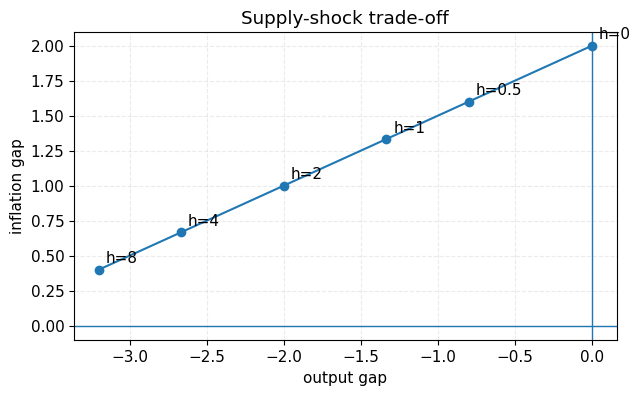

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(tradeoff["y_gap"], tradeoff["pi_gap"], marker="o")
for _, row in tradeoff.iterrows():
    ax.annotate(f"h={row['h']:g}", (row["y_gap"], row["pi_gap"]), textcoords="offset points", xytext=(5, 5))
ax.axhline(0, linewidth=1)
ax.axvline(0, linewidth=1)
ax.set_title("Supply-shock trade-off")
ax.set_xlabel("output gap")
ax.set_ylabel("inflation gap")
plt.show()

**Interpretation.** Demand shocks can be offset by moving demand in the opposite direction. Supply shocks are harder because inflation and output move in opposite directions.

## 4. Inflation bias and credibility

In the Barro-Gordon logic, the policymaker would like output above its structural level. Surprise inflation can temporarily raise output, but rational expectations remove the surprise. The result is an inflation bias: inflation is too high, while output is not above the structural level.

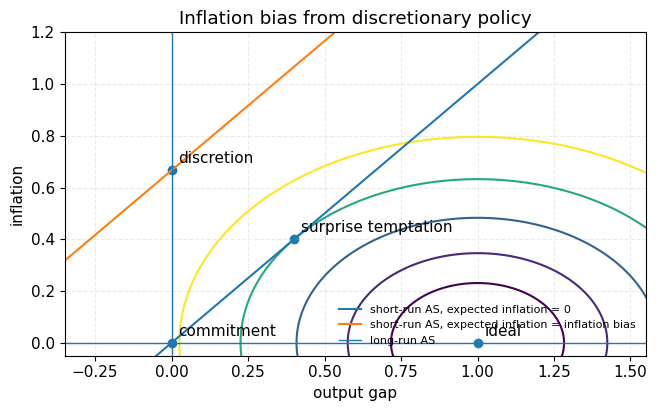

In [9]:
omega = 1.0
kappa = 1.5

y = np.linspace(-0.4, 1.7, 250)
pi = np.linspace(-0.1, 1.3, 220)
Y, P = np.meshgrid(y, pi)
loss = (Y - omega) ** 2 + kappa * P ** 2

fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.contour(Y, P, loss, levels=[0.08, 0.18, 0.35, 0.60, 0.95])
ax.plot(y, y, label="short-run AS, expected inflation = 0")
ax.plot(y, omega / kappa + y, label="short-run AS, expected inflation = inflation bias")
ax.axvline(0, linewidth=1, label="long-run AS")
ax.axhline(0, linewidth=1)

points = pd.DataFrame({
    "point": ["commitment", "surprise temptation", "discretion", "ideal"],
    "y_gap": [0, omega / (1 + kappa), 0, omega],
    "pi": [0, omega / (1 + kappa), omega / kappa, 0],
})
ax.scatter(points["y_gap"], points["pi"])
for _, row in points.iterrows():
    ax.annotate(row["point"], (row["y_gap"], row["pi"]), textcoords="offset points", xytext=(5, 5))

ax.set_xlim(-0.35, 1.55)
ax.set_ylim(-0.05, 1.2)
ax.set_xlabel("output gap")
ax.set_ylabel("inflation")
ax.set_title("Inflation bias from discretionary policy")
ax.legend(frameon=False, fontsize=8)
plt.show()

## 5. Mixed expectations

Pure rational expectations is a benchmark. A simple way to deviate from it is to let expectations be partly backward-looking:

\[
\pi^e_{t,t-1}=\lambda\pi_{t-1}+(1-\lambda)E(\pi_t\mid I_{t-1}),
\qquad 0\leq\lambda\leq 1.
\]

Higher \(\lambda\) means expectations place more weight on last period's inflation.

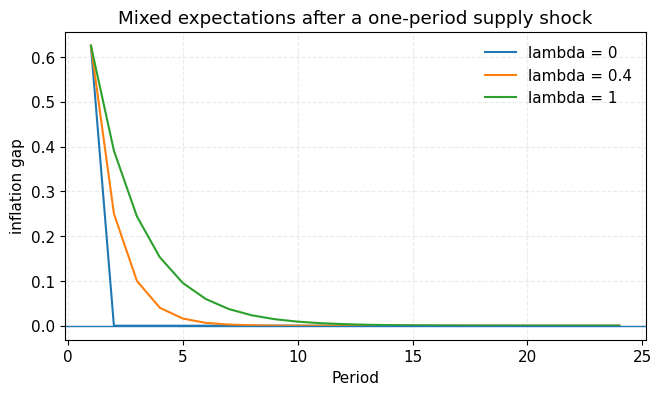

In [10]:
T = 24
a = 1.2
Gamma = 0.5
lambdas = [0.0, 0.4, 1.0]

paths = []
for lam in lambdas:
    pi_gap = np.zeros(T)
    for t in range(T):
        s_t = 1.0 if t == 0 else 0.0
        carry = 0.0 if lam == 0 else lam / (lam + a * Gamma)
        pi_gap[t] = (carry * pi_gap[t - 1] if t > 0 else 0.0) + s_t / (1 + a * Gamma)
    paths.append(pd.DataFrame({"period": np.arange(1, T + 1), "lambda": lam, "pi_gap": pi_gap}))

mixed_df = pd.concat(paths, ignore_index=True)

fig, ax = plt.subplots(figsize=(7.5, 4))
for lam, group in mixed_df.groupby("lambda"):
    ax.plot(group["period"], group["pi_gap"], label=f"lambda = {lam:g}")
ax.axhline(0, linewidth=1)
ax.set_title("Mixed expectations after a one-period supply shock")
ax.set_xlabel("Period")
ax.set_ylabel("inflation gap")
ax.legend(frameon=False)
plt.show()

## Final check

For an exam answer, keep the mechanism in this order:

1. define the shock,
2. state who had which information when expectations were formed,
3. identify whether the central bank can create an information-based response,
4. separate demand shocks from supply shocks,
5. discuss credibility and data uncertainty if the question is about real-world policy.